## <center>  Data Science Essentials (CIA2C14)</center>
### <center>  Practical 3 : Data Preparation with Pandas </center>

# Goals:
###1. Practice basic exploration: Spot, measure, visualise missing data
###2. Impute
###3. Compare


#Lets Load

In [42]:
import pandas as pd
import numpy as np
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/DSES")
#if you still cant load, time to panic.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
df = pd.read_csv('loan_data.csv')
df

,loan_amt,loan_paid,risk_rating,sector
0,1000,1000,A,Retail
1,1000,1000,AA,Finance
2,1000,1000,AA,Manufacturing
3,1000,1000,B,Retail
4,1000,1000,BB,Healthcare
...,...,...,...,...
818,23000,19100,AA,Technology
819,23000,19100,BB,Finance
820,24000,21800,AAA,Manufacturing
821,24000,20900,A,Technology


##What should we do now?

##Exploration!

In [44]:
#rem from our previous practical lab?
df.describe(include='all')

,loan_amt,loan_paid,risk_rating,sector
count,823.000000,823.000000,823,732
unique,NaN,NaN,5,6
top,NaN,NaN,A,Retail
freq,NaN,NaN,245,206
mean,9948.967193,8969.501823,NaN,NaN
std,4836.481476,4387.463408,NaN,NaN
min,1000.000000,800.000000,NaN,NaN
25%,7000.000000,5900.000000,NaN,NaN
50%,10000.000000,8800.000000,NaN,NaN
75%,13000.000000,11950.000000,NaN,NaN


In [45]:
#describe doesnt tell us much about object columns. what should we do?
print((df['risk_rating']).value_counts())
print((df['sector']).value_counts())

risk_rating
A      245
BB     204
AA     170
B      117
AAA     87
Name: count, dtype: int64
sector
Retail           206
Manufacturing    178
Finance          165
Technology       106
Healthcare        62
Agriculture       15
Name: count, dtype: int64


In [46]:
#for this lab, lets introduce random 20% missing for loan_amt
df_missing = df.copy()
df_missing['loan_amt'] = np.where(np.random.rand(len(df_missing)) < 0.2, np.nan, df_missing['loan_amt'])
df_missing

,loan_amt,loan_paid,risk_rating,sector
0,NaN,1000,A,Retail
1,1000.0,1000,AA,Finance
2,1000.0,1000,AA,Manufacturing
3,1000.0,1000,B,Retail
4,1000.0,1000,BB,Healthcare
...,...,...,...,...
818,23000.0,19100,AA,Technology
819,NaN,19100,BB,Finance
820,24000.0,21800,AAA,Manufacturing
821,24000.0,20900,A,Technology


In [47]:
df_missing.isnull().sum()
#did u notice missing sector info, before we created missing values in loan_amt?

,0
loan_amt,155
loan_paid,0
risk_rating,0
sector,91


<font color = red> Tutor NOT to run null values check. For students to self complete codes as prep for in-class assignment.

In [48]:
#lets check where/when is df_missing loan_amt is null
df_missing[df_missing['loan_amt'].isnull()]

,loan_amt,loan_paid,risk_rating,sector
0,NaN,1000,A,Retail
21,NaN,800,AA,Manufacturing
29,NaN,900,BB,NaN
35,NaN,800,AAA,Technology
36,NaN,1000,BB,Finance
...,...,...,...,...
797,NaN,17700,AAA,Manufacturing
801,NaN,17700,BB,Manufacturing
803,NaN,16200,AAA,Manufacturing
813,NaN,17000,A,Finance


In [49]:
#store index of df loan_amt is null. will be useful later to 'painting' plots with data points that were imputed vs original.
null_index = df_missing[df_missing['loan_amt'].isnull()].index
null_index

Index([  0,  21,  29,  35,  36,  40,  41,  49,  53,  64,
       ...
       763, 766, 767, 768, 790, 797, 801, 803, 813, 819],
      dtype='int64', length=155)

<Axes: >

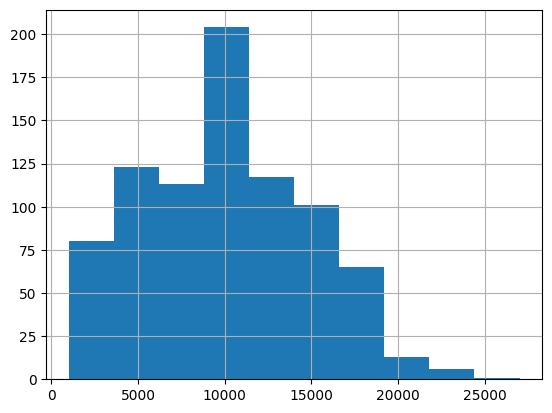

In [50]:
df['loan_amt'].hist()

<Axes: >

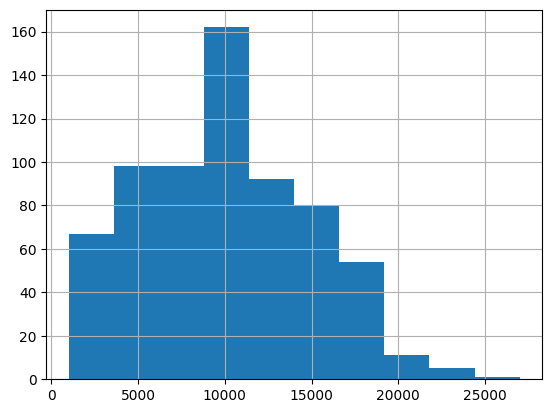

In [51]:
df_missing['loan_amt'].hist()

<Axes: >

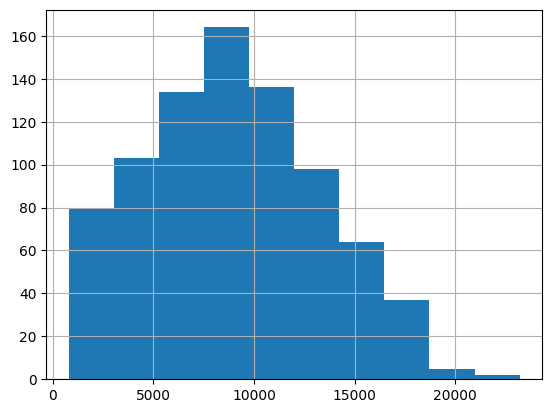

In [52]:
df['loan_paid'].hist()

<Axes: >

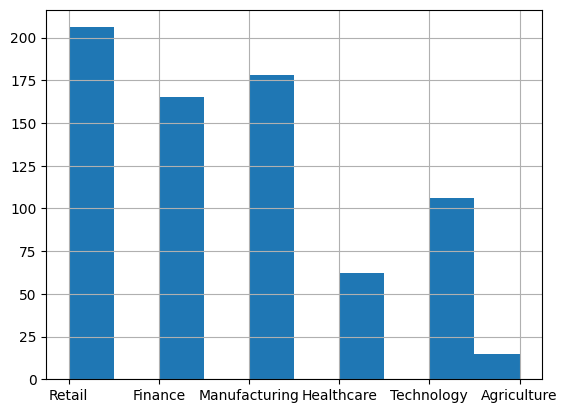

In [53]:
df['sector'].hist()

<Axes: >

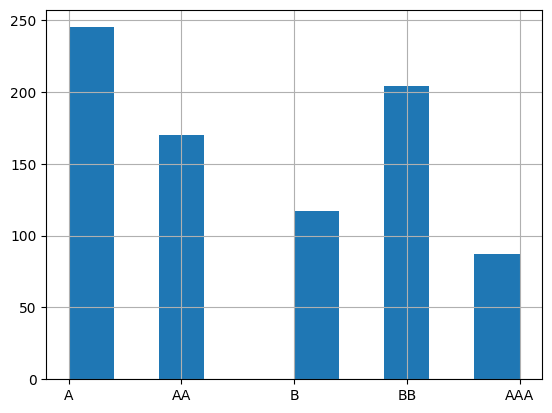

In [54]:
df['risk_rating'].hist()

In [55]:
from sklearn.impute import SimpleImputer
mean_imp = SimpleImputer(strategy='mean')
df_missing['loan_amt_mean'] = mean_imp.fit_transform(df_missing[['loan_amt']])

median_imp = SimpleImputer(strategy='median')
df_missing['loan_amt_median'] = median_imp.fit_transform(df_missing[['loan_amt']])

mode_imp = SimpleImputer(strategy='most_frequent')
df_missing['sector_mode'] = mode_imp.fit_transform(df_missing[['sector']]).squeeze()
#Without .squeeze(), assignment would fail because the left-hand side is a single column.

In [56]:
df.describe(include='all')

,loan_amt,loan_paid,risk_rating,sector
count,823.000000,823.000000,823,732
unique,NaN,NaN,5,6
top,NaN,NaN,A,Retail
freq,NaN,NaN,245,206
mean,9948.967193,8969.501823,NaN,NaN
std,4836.481476,4387.463408,NaN,NaN
min,1000.000000,800.000000,NaN,NaN
25%,7000.000000,5900.000000,NaN,NaN
50%,10000.000000,8800.000000,NaN,NaN
75%,13000.000000,11950.000000,NaN,NaN


In [57]:
df_missing.describe(include='all')

,loan_amt,loan_paid,risk_rating,sector,loan_amt_mean,loan_amt_median,sector_mode
count,668.000000,823.000000,823,732,823.000000,823.000000,823
unique,NaN,NaN,5,6,NaN,NaN,6
top,NaN,NaN,A,Retail,NaN,NaN,Retail
freq,NaN,NaN,245,206,NaN,NaN,297
mean,9908.682635,8969.501823,NaN,NaN,9908.682635,9925.880923,NaN
std,4882.338154,4387.463408,NaN,NaN,4397.996342,4398.141437,NaN
min,1000.000000,800.000000,NaN,NaN,1000.000000,1000.000000,NaN
25%,7000.000000,5900.000000,NaN,NaN,7000.000000,7000.000000,NaN
50%,10000.000000,8800.000000,NaN,NaN,9908.682635,10000.000000,NaN
75%,13000.000000,11950.000000,NaN,NaN,12000.000000,12000.000000,NaN


Qn: What do you observe? <br><br>
Ans: describe did not change much as expected, as we fill it with central tendency values. But is it true? Lets check.

<Axes: >

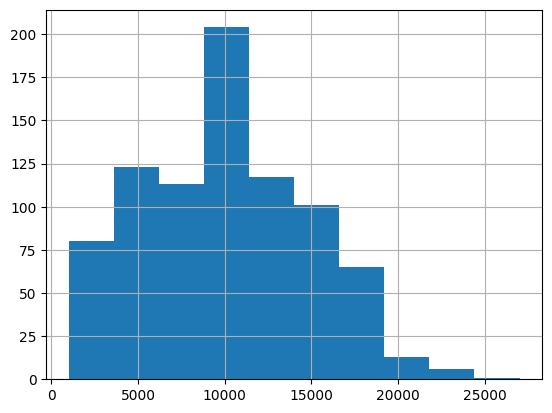

In [58]:
df['loan_amt'].hist()

<Axes: >

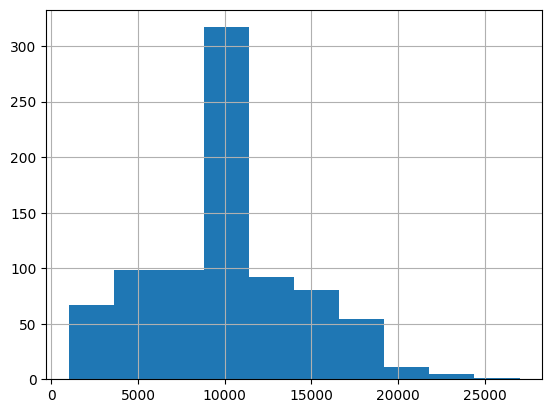

In [59]:
df_missing['loan_amt_mean'].hist()

<Axes: >

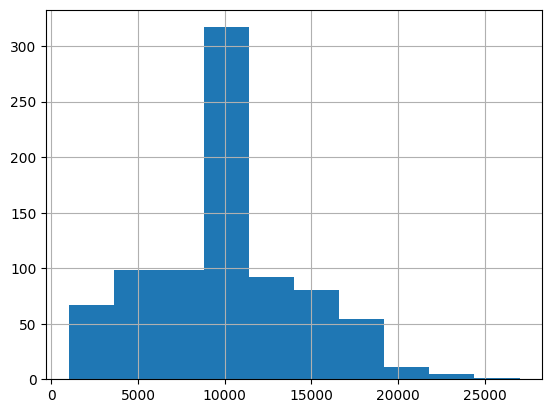

In [60]:
df_missing['loan_amt_median'].hist()

<Axes: >

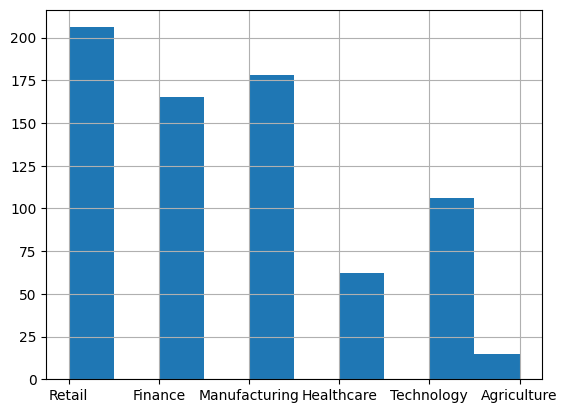

In [61]:
df['sector'].hist()

<Axes: >

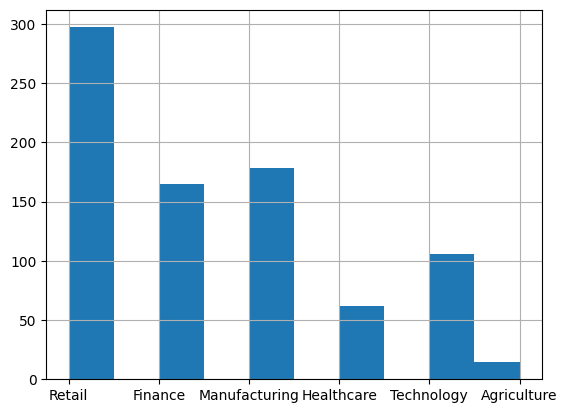

In [62]:
df_missing['sector_mode'].hist()

Qn: What do you observe? <br><br>
Ans: hist show the shape have not been preserved. Lets try something 'smarter'. For example: When you forget a friend’s favourite ice-cream flavour, you look at the three pals closest in age and maybe game preference; if two prefer chocolate, you assume that friend likes chocolate too. That “nearest-neighbours” guess is exactly what KNNImputer does with missing data.


In [65]:
from sklearn.impute import KNNImputer
import numpy as np

# simple ordinal map for risk_rating first. like all, if not most, algorithm can only process numbers.
rating_map = {'B': 1, 'BB': 2, 'A': 3, 'AA': 4, 'AAA': 5}
df_missing['risk_rating_code'] = df_missing['risk_rating'].map(rating_map)

# quick numeric code for sector (‑1 = missing)
df_missing['sector_code'] = df_missing['sector_mode'].astype('category').cat.codes

knn_features = ['loan_amt', 'loan_paid',
                'risk_rating_code', 'sector_code']

knn_imp = KNNImputer(n_neighbors=5)
loan_amt_knn = knn_imp.fit_transform(df_missing[knn_features])[:, 0]

df_missing['loan_amt_knn'] = np.round(loan_amt_knn, -3)


<Axes: >

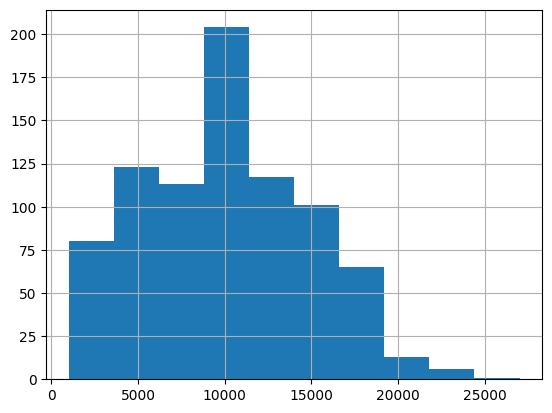

In [66]:
df['loan_amt'].hist()

<Axes: >

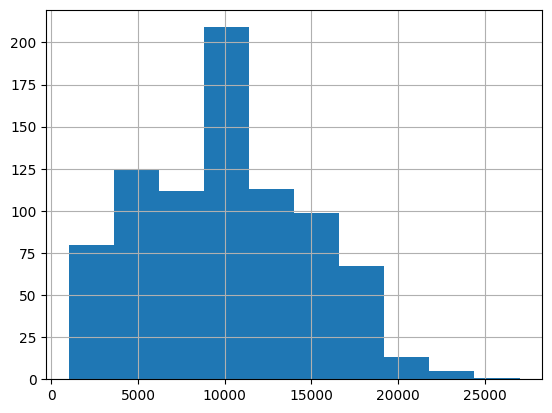

In [67]:
df_missing['loan_amt_knn'].hist()

hist show distribution have been preserved!

In [69]:
#create a newcolumn imputed 1 for null_index
df_missing['imputed'] = 0
df_missing.loc[null_index, 'imputed'] = 1
df_missing

,loan_amt,loan_paid,risk_rating,sector,loan_amt_mean,loan_amt_median,sector_mode,risk_rating_code,sector_code,loan_amt_knn,imputed
0,NaN,1000,A,Retail,9908.682635,10000.0,Retail,3,4,1000.0,1
1,1000.0,1000,AA,Finance,1000.000000,1000.0,Finance,4,1,1000.0,0
2,1000.0,1000,AA,Manufacturing,1000.000000,1000.0,Manufacturing,4,3,1000.0,0
3,1000.0,1000,B,Retail,1000.000000,1000.0,Retail,1,4,1000.0,0
4,1000.0,1000,BB,Healthcare,1000.000000,1000.0,Healthcare,2,2,1000.0,0
...,...,...,...,...,...,...,...,...,...,...,...
818,23000.0,19100,AA,Technology,23000.000000,23000.0,Technology,4,5,23000.0,0
819,NaN,19100,BB,Finance,9908.682635,10000.0,Finance,2,1,21000.0,1
820,24000.0,21800,AAA,Manufacturing,24000.000000,24000.0,Manufacturing,5,3,24000.0,0
821,24000.0,20900,A,Technology,24000.000000,24000.0,Technology,3,5,24000.0,0


<Axes: xlabel='loan_amt', ylabel='loan_paid'>

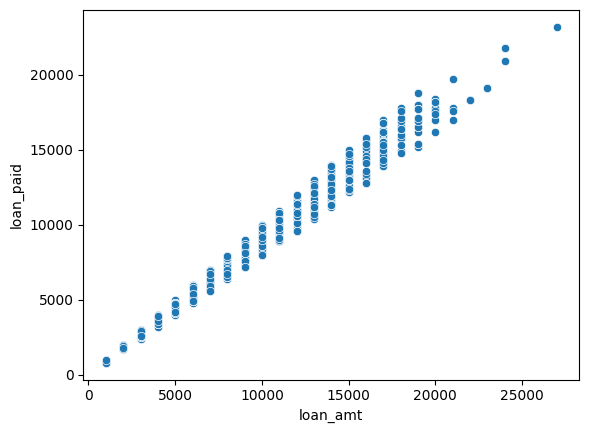

In [71]:
#scatter plot of loan_amt and loan_paid
from matplotlib import pyplot as plt
import seaborn as sns
sns.scatterplot(data=df, x='loan_amt', y='loan_paid')

<Axes: xlabel='loan_amt_mean', ylabel='loan_paid'>

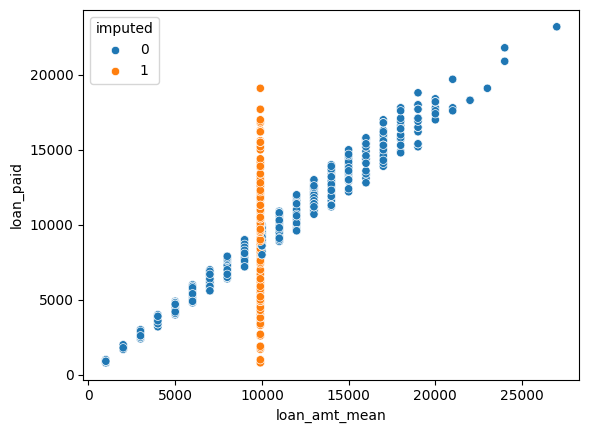

In [72]:
sns.scatterplot(data=df_missing, x='loan_amt_mean', y='loan_paid', hue='imputed')

<Axes: xlabel='loan_amt_median', ylabel='loan_paid'>

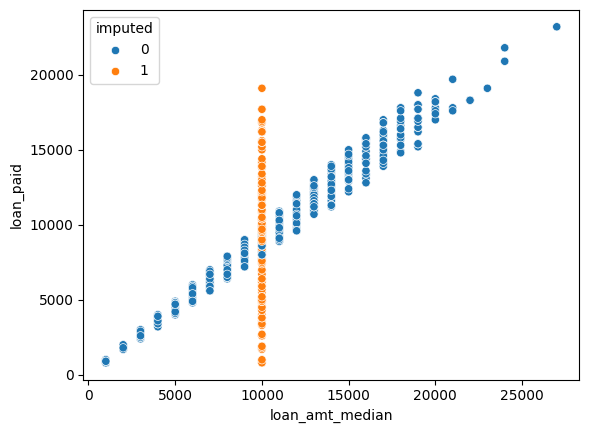

In [73]:
sns.scatterplot(data=df_missing, x='loan_amt_median', y='loan_paid', hue='imputed')

<Axes: xlabel='loan_amt_knn', ylabel='loan_paid'>

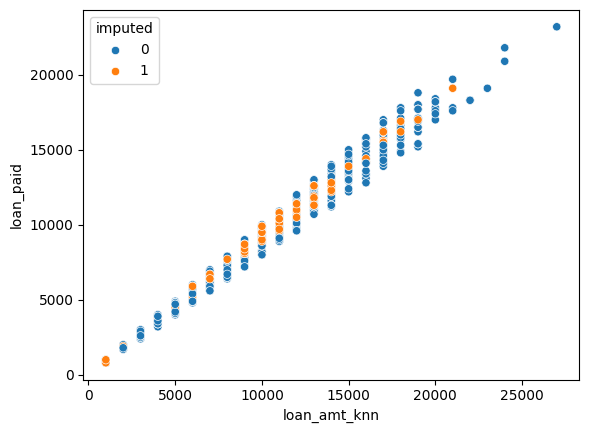

In [74]:
sns.scatterplot(data=df_missing, x='loan_amt_knn', y='loan_paid', hue='imputed')

In [75]:
df_missing

,loan_amt,loan_paid,risk_rating,sector,loan_amt_mean,loan_amt_median,sector_mode,risk_rating_code,sector_code,loan_amt_knn,imputed
0,NaN,1000,A,Retail,9908.682635,10000.0,Retail,3,4,1000.0,1
1,1000.0,1000,AA,Finance,1000.000000,1000.0,Finance,4,1,1000.0,0
2,1000.0,1000,AA,Manufacturing,1000.000000,1000.0,Manufacturing,4,3,1000.0,0
3,1000.0,1000,B,Retail,1000.000000,1000.0,Retail,1,4,1000.0,0
4,1000.0,1000,BB,Healthcare,1000.000000,1000.0,Healthcare,2,2,1000.0,0
...,...,...,...,...,...,...,...,...,...,...,...
818,23000.0,19100,AA,Technology,23000.000000,23000.0,Technology,4,5,23000.0,0
819,NaN,19100,BB,Finance,9908.682635,10000.0,Finance,2,1,21000.0,1
820,24000.0,21800,AAA,Manufacturing,24000.000000,24000.0,Manufacturing,5,3,24000.0,0
821,24000.0,20900,A,Technology,24000.000000,24000.0,Technology,3,5,24000.0,0


<font color=red> tutor to use interactive table and show amt_paid sort descending, those imputed are an average of nearby 5 points (becos of k neighbor = 5). tutor to ask students what is the difference between this knnimputer and moving average? Ans: moving average is done by manual sorting, limited to look at column by column, cannot look across all columns at the same time like knn would. <br><br> using knn, the imputer look at other 'similar' points then assume the missing value isnt far off. </font>